# Credit Sales Invoice — Full EDA

**Goal:** Diagnose structural patterns, data quality issues, and feature engineering opportunities to improve downstream payment-delay classification.

**Sections**
1. Setup & load
2. Dataset overview
3. Target distribution & class imbalance
4. Missing value audit
5. Payment history features (DTP)
6. Financial features
7. Plan type analysis
8. Temporal patterns & seasonality
9. Repeat-payer behaviour & bracket transitions
10. Outlier audit
11. Correlation & feature importance signals
12. Feature engineering recommendations

## 1. Setup & load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

BRACKET_ORDER = ['on_time', '30_days', '60_days', '90_days']
BRACKET_COLORS = {'on_time': '#1D9E75', '30_days': '#378ADD', '60_days': '#BA7517', '90_days': '#D85A30'}
PALETTE = [BRACKET_COLORS[b] for b in BRACKET_ORDER]

df = pd.read_excel('credit_sale_invoices.xlsx')
df['dtp_bracket'] = pd.Categorical(df['dtp_bracket'], categories=BRACKET_ORDER, ordered=True)
df['due_month'] = df['due_date'].dt.month
df['due_year']  = df['due_date'].dt.year
df['due_quarter'] = df['due_date'].dt.quarter
df['target_enc'] = df['dtp_bracket'].cat.codes  # on_time=0 ... 90_days=3

print(f'Rows: {len(df):,}  |  Columns: {df.shape[1]}  |  Students: {df["student_id_pseudonimized"].nunique():,}')

Rows: 10,350  |  Columns: 37  |  Students: 957


## 2. Dataset overview

In [2]:
display(df.dtypes.to_frame('dtype').join(df.isnull().sum().to_frame('nulls')))
display(df.describe(include='all').T[['count','mean','std','min','50%','max']])

,dtype,nulls
school_year,int64,0
student_id_pseudonimized,object,0
category_name,object,0
gross_receivables,float64,0
amount_discounted,float64,0
adjustments,float64,0
credit_sale_amount,float64,0
due_date,datetime64[ns],0
date_fully_paid,datetime64[ns],703
days_elapsed_until_fully_paid,int64,0


,count,mean,std,min,50%,max
school_year,10350.0,2022.908019,1.789169,2016.0,2023.0,2026.0
student_id_pseudonimized,10350,NaN,NaN,NaN,NaN,NaN
category_name,10350,NaN,NaN,NaN,NaN,NaN
gross_receivables,10350.0,4489.203502,3654.609308,6.0,4133.0,169190.0
amount_discounted,10350.0,-70.60872,504.361619,-13957.0,0.0,0.0
adjustments,10350.0,-1.236691,42.060431,-2142.0,0.0,0.0
credit_sale_amount,10350.0,4417.358092,3597.605368,6.0,4133.0,169190.0
due_date,10350,2023-10-14 16:03:37.043478272,NaN,2016-01-01 00:00:00,2023-12-08 00:00:00,2026-08-07 00:00:00
date_fully_paid,9647,2023-10-31 13:00:22.763553536,NaN,2018-05-11 00:00:00,2024-01-04 00:00:00,2026-03-13 00:00:00
days_elapsed_until_fully_paid,10350.0,75.657005,265.185565,-288.0,7.0,3636.0


## 3. Target distribution & class imbalance

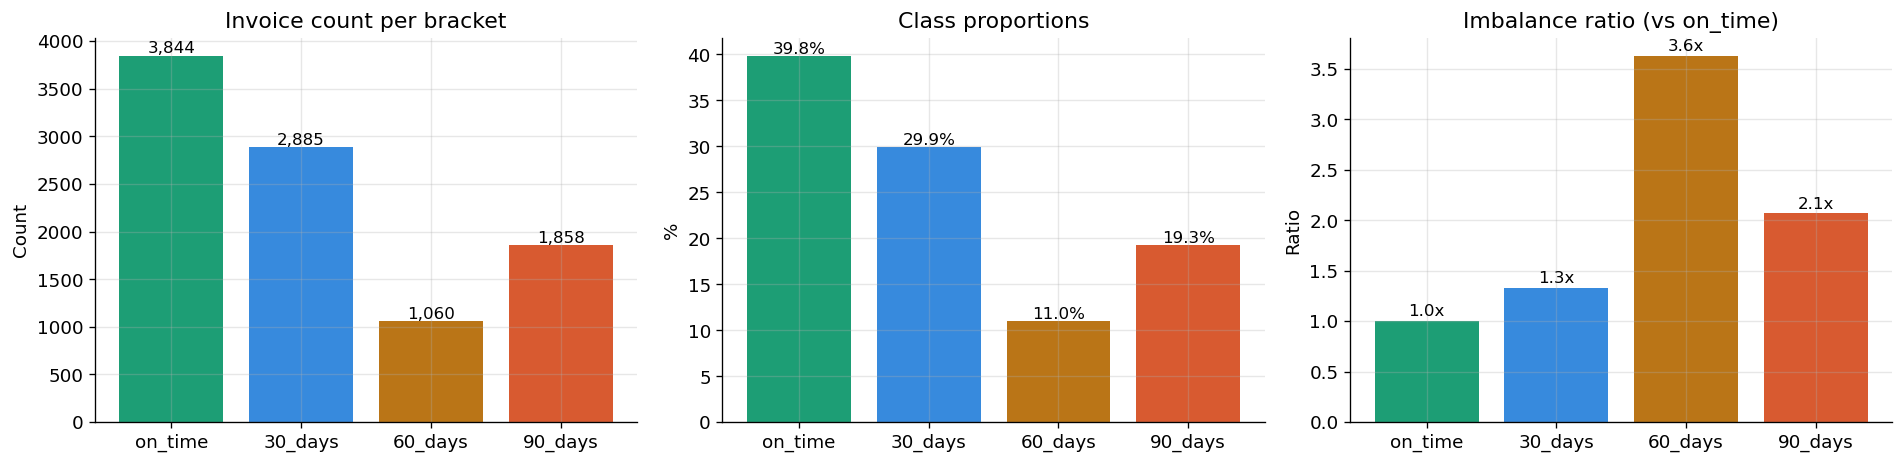


Imbalance summary:
             count   pct
dtp_bracket             
on_time       3844  39.8
30_days       2885  29.9
60_days       1060  11.0
90_days       1858  19.3

Minority class (60_days) is 3.6x less represented than on_time


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Count
counts = df['dtp_bracket'].value_counts()[BRACKET_ORDER]
axes[0].bar(BRACKET_ORDER, counts.values, color=PALETTE)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, f'{v:,}', ha='center', fontsize=10)
axes[0].set_title('Invoice count per bracket')
axes[0].set_ylabel('Count')

# Proportion
props = counts / counts.sum()
axes[1].bar(BRACKET_ORDER, props.values * 100, color=PALETTE)
for i, v in enumerate(props.values):
    axes[1].text(i, v * 100 + 0.3, f'{v:.1%}', ha='center', fontsize=10)
axes[1].set_title('Class proportions')
axes[1].set_ylabel('%')

# Imbalance ratio relative to majority
ratios = counts.max() / counts
axes[2].bar(BRACKET_ORDER, ratios.values, color=PALETTE)
for i, v in enumerate(ratios.values):
    axes[2].text(i, v + 0.05, f'{v:.1f}x', ha='center', fontsize=10)
axes[2].set_title('Imbalance ratio (vs on_time)')
axes[2].set_ylabel('Ratio')

plt.tight_layout()
plt.show()

print('\nImbalance summary:')
print(counts.to_frame('count').assign(pct=lambda x: (x['count']/x['count'].sum()*100).round(1)))
print(f'\nMinority class (60_days) is {ratios["60_days"]:.1f}x less represented than on_time')

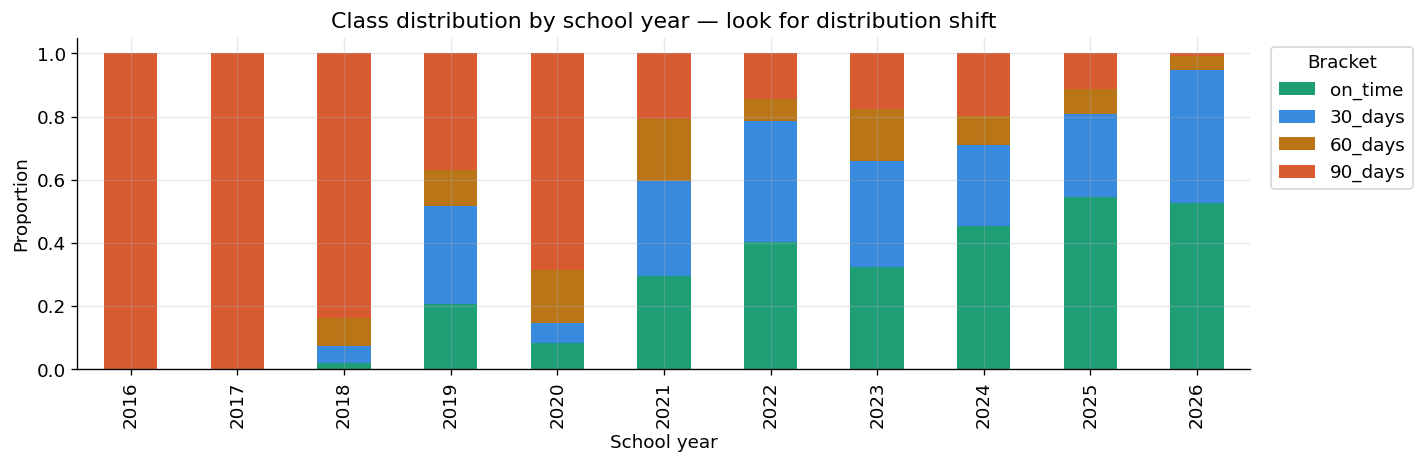


Note: 2016-2018 are dominated by 90_days. Check if including these years biases the model.


In [4]:
# Class distribution by school year — reveals dataset shift
yearly = df.groupby('due_year')['dtp_bracket'].value_counts(normalize=True).unstack()[BRACKET_ORDER]
yearly.plot(kind='bar', stacked=True, figsize=(12, 4), color=PALETTE)
plt.title('Class distribution by school year — look for distribution shift')
plt.ylabel('Proportion')
plt.xlabel('School year')
plt.legend(title='Bracket', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()
print('\nNote: 2016-2018 are dominated by 90_days. Check if including these years biases the model.')

## 4. Missing value audit

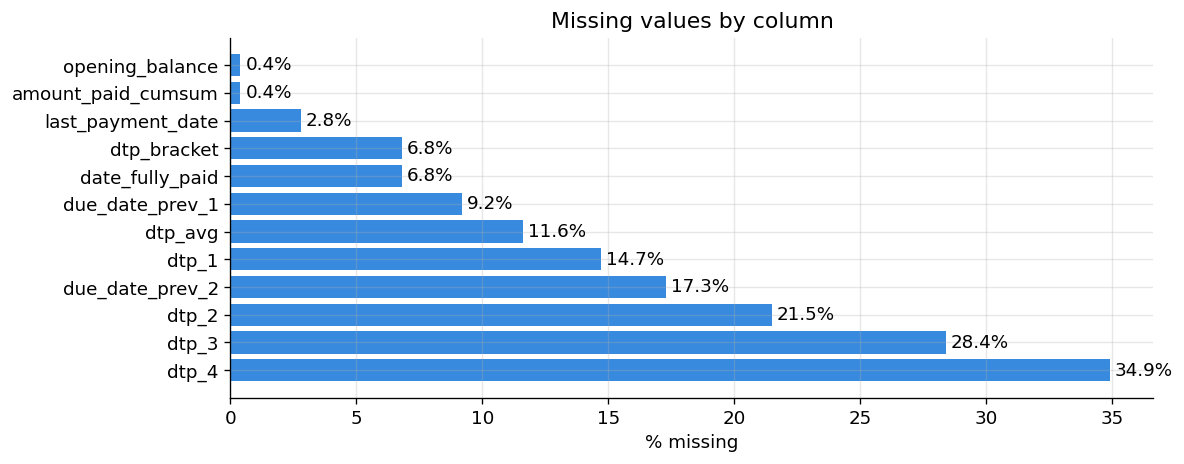


Missing detail:
                    count   pct                                    reason
dtp_4                3614  34.9          First invoice — no prior history
dtp_3                2936  28.4          First invoice — no prior history
dtp_2                2229  21.5          First invoice — no prior history
due_date_prev_2      1788  17.3                         No prior invoices
dtp_1                1521  14.7          First invoice — no prior history
dtp_avg              1205  11.6          First invoice — no prior history
due_date_prev_1       957   9.2                         No prior invoices
date_fully_paid       703   6.8  Uncensored records — no payment date yet
dtp_bracket           703   6.8          First invoice — no prior history
last_payment_date     287   2.8                          No prior payment
amount_paid_cumsum     37   0.4                    Missing financial data
opening_balance        37   0.4                    Missing financial data

Target distribution 

In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
pct = (missing / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(missing.index, pct.values, color='#378ADD')
for bar, val in zip(bars, pct.values):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val}%', va='center')
ax.set_xlabel('% missing')
ax.set_title('Missing values by column')
plt.tight_layout()
plt.show()

print('\nMissing detail:')
print(pd.DataFrame({'count': missing, 'pct': pct, 'reason': [
    'Uncensored records — no payment date yet' if c == 'date_fully_paid' else
    'First invoice — no prior history' if c.startswith('dtp') else
    'No prior invoices' if c.startswith('due_date_prev') else
    'Uncensored (no payment yet)' if c == 'dtp_bracket' else
    'No prior payment' if c == 'last_payment_date' else
    'Missing financial data'
    for c in missing.index
]}))

# Is missingness in DTP correlated with the target?
df['dtp1_missing'] = df['dtp_1'].isnull().astype(int)
print('\nTarget distribution when dtp_1 is MISSING vs present:')
print(df.groupby('dtp1_missing')['dtp_bracket'].value_counts(normalize=True).unstack()[BRACKET_ORDER].round(3))

## 5. Payment history features (DTP analysis)

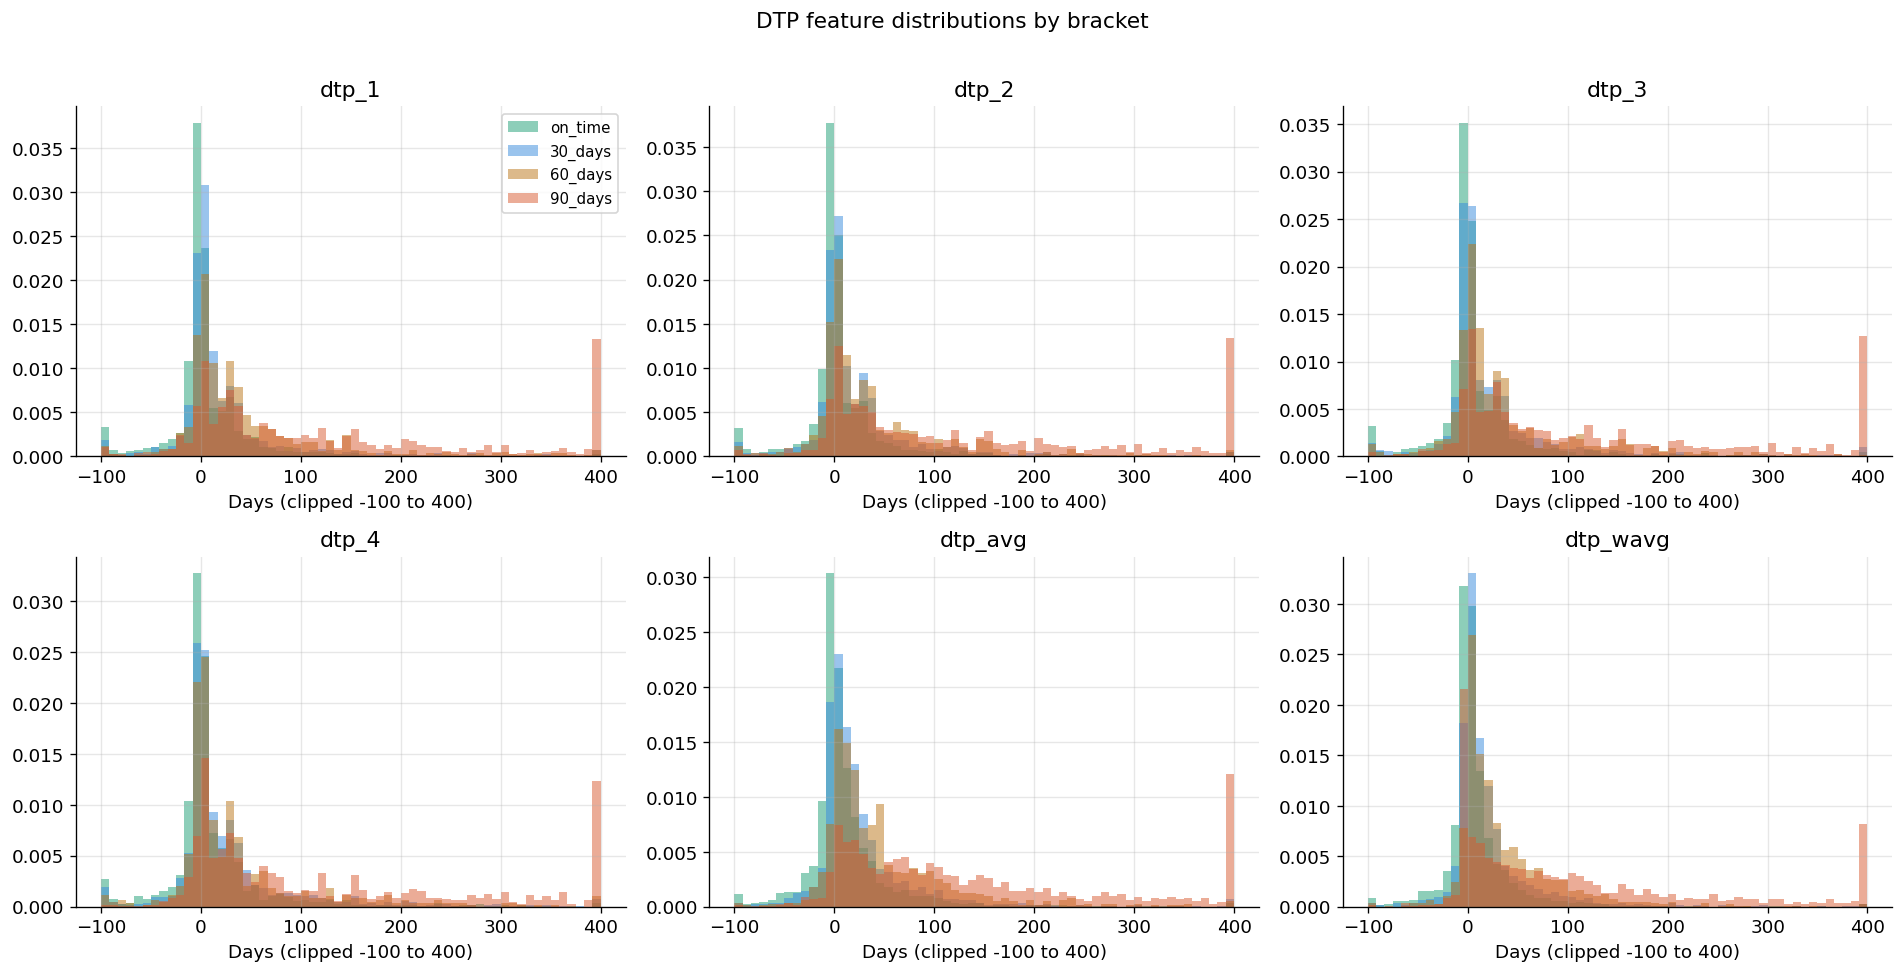

In [6]:
dtp_cols = ['dtp_1', 'dtp_2', 'dtp_3', 'dtp_4', 'dtp_avg', 'dtp_wavg']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(dtp_cols):
    for bracket in BRACKET_ORDER:
        vals = df[df['dtp_bracket'] == bracket][col].dropna()
        # Clip for readability
        vals = vals.clip(-100, 400)
        axes[i].hist(vals, bins=60, alpha=0.5, label=bracket, color=BRACKET_COLORS[bracket], density=True)
    axes[i].set_title(col)
    axes[i].set_xlabel('Days (clipped -100 to 400)')
    if i == 0:
        axes[i].legend(fontsize=9)

plt.suptitle('DTP feature distributions by bracket', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [7]:
# Negative DTP values — early payers — are these a useful signal?
neg_dtp = (df['dtp_1'] < 0)
print('Target distribution for EARLY payers (dtp_1 < 0):')
print(df[neg_dtp]['dtp_bracket'].value_counts(normalize=True).round(3))
print('\nTarget distribution for LATE payers (dtp_1 > 0):')
print(df[df['dtp_1'] > 0]['dtp_bracket'].value_counts(normalize=True).round(3))

# Suggest: binary early-payer flag
df['early_payer_flag'] = (df['dtp_1'] < 0).astype(int)
print('\nCross-tab: early_payer_flag vs bracket')
print(pd.crosstab(df['early_payer_flag'], df['dtp_bracket'], normalize='index').round(3))

Target distribution for EARLY payers (dtp_1 < 0):
dtp_bracket
on_time    0.606
30_days    0.273
60_days    0.062
90_days    0.059
Name: proportion, dtype: float64

Target distribution for LATE payers (dtp_1 > 0):
dtp_bracket
30_days    0.323
on_time    0.283
90_days    0.255
60_days    0.138
Name: proportion, dtype: float64

Cross-tab: early_payer_flag vs bracket
dtp_bracket       on_time  30_days  60_days  90_days
early_payer_flag                                    
0                   0.304    0.311    0.132    0.253
1                   0.606    0.273    0.062    0.059


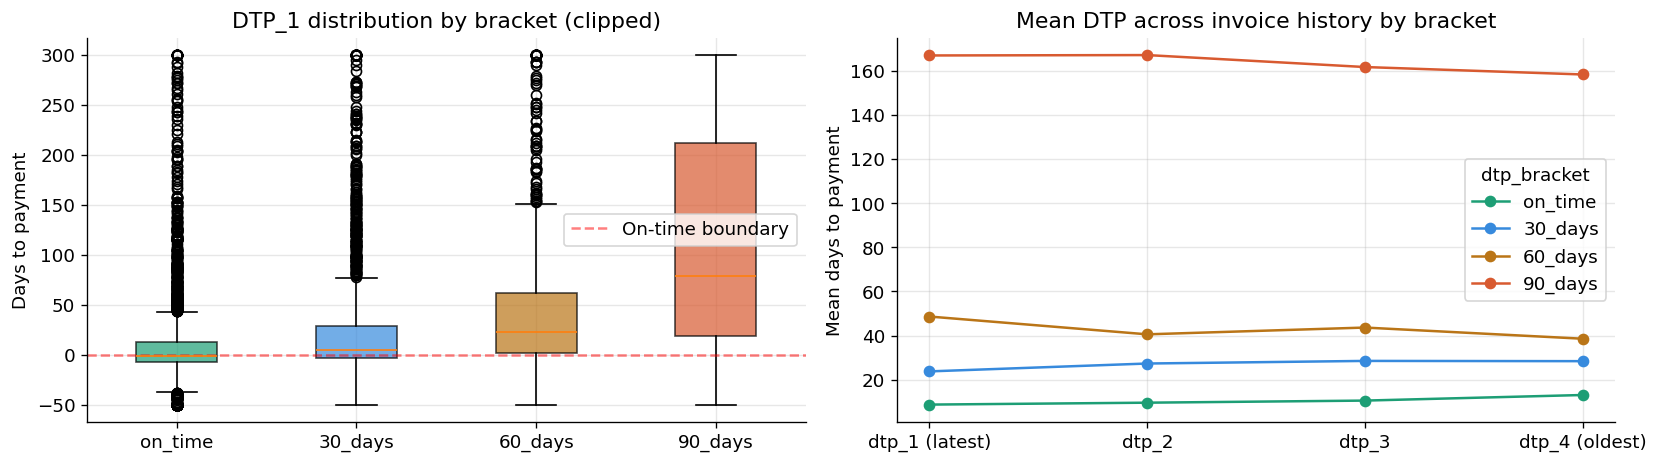

In [8]:
# DTP trend — is the account getting better or worse?
df['dtp_improving'] = (df['dtp_1'] < df['dtp_2']).astype(float)  # 1 = improving, 0 = worsening

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Box plot of dtp_1 by bracket (outliers removed)
data_box = [df[df['dtp_bracket']==b]['dtp_1'].clip(-50, 300).dropna() for b in BRACKET_ORDER]
bp = axes[0].boxplot(data_box, labels=BRACKET_ORDER, patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('DTP_1 distribution by bracket (clipped)')
axes[0].set_ylabel('Days to payment')
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5, label='On-time boundary')
axes[0].legend()

# Rolling mean DTP trend
dtp_trend_by_bracket = df.groupby('dtp_bracket')[['dtp_1','dtp_2','dtp_3','dtp_4']].mean()
dtp_trend_by_bracket.T.plot(ax=axes[1], color=PALETTE, marker='o')
axes[1].set_title('Mean DTP across invoice history by bracket')
axes[1].set_ylabel('Mean days to payment')
axes[1].set_xticks([0,1,2,3])
axes[1].set_xticklabels(['dtp_1 (latest)','dtp_2','dtp_3','dtp_4 (oldest)'])

plt.tight_layout()
plt.show()

In [9]:
# Autocorrelation: does DTP_1 predict current bracket better than DTP_4?
from scipy.stats import pointbiserialr, spearmanr

print('Spearman correlation with target (ordinal encoded):')
for col in dtp_cols:
    valid = df[['target_enc', col]].dropna()
    r, p = spearmanr(valid['target_enc'], valid[col])
    print(f'  {col:<12} r={r:.3f}  p={p:.1e}  ({"significant" if p < 0.001 else "not significant"})')

print('\nKey insight: if dtp_1 has higher correlation than dtp_4, recency matters more than history depth.')

Spearman correlation with target (ordinal encoded):
  dtp_1        r=0.385  p=1.2e-309  (significant)
  dtp_2        r=0.365  p=9.6e-255  (significant)
  dtp_3        r=0.336  p=5.8e-195  (significant)
  dtp_4        r=0.286  p=1.0e-126  (significant)
  dtp_avg      r=0.402  p=0.0e+00  (significant)
  dtp_wavg     r=0.378  p=0.0e+00  (significant)

Key insight: if dtp_1 has higher correlation than dtp_4, recency matters more than history depth.


## 6. Financial features

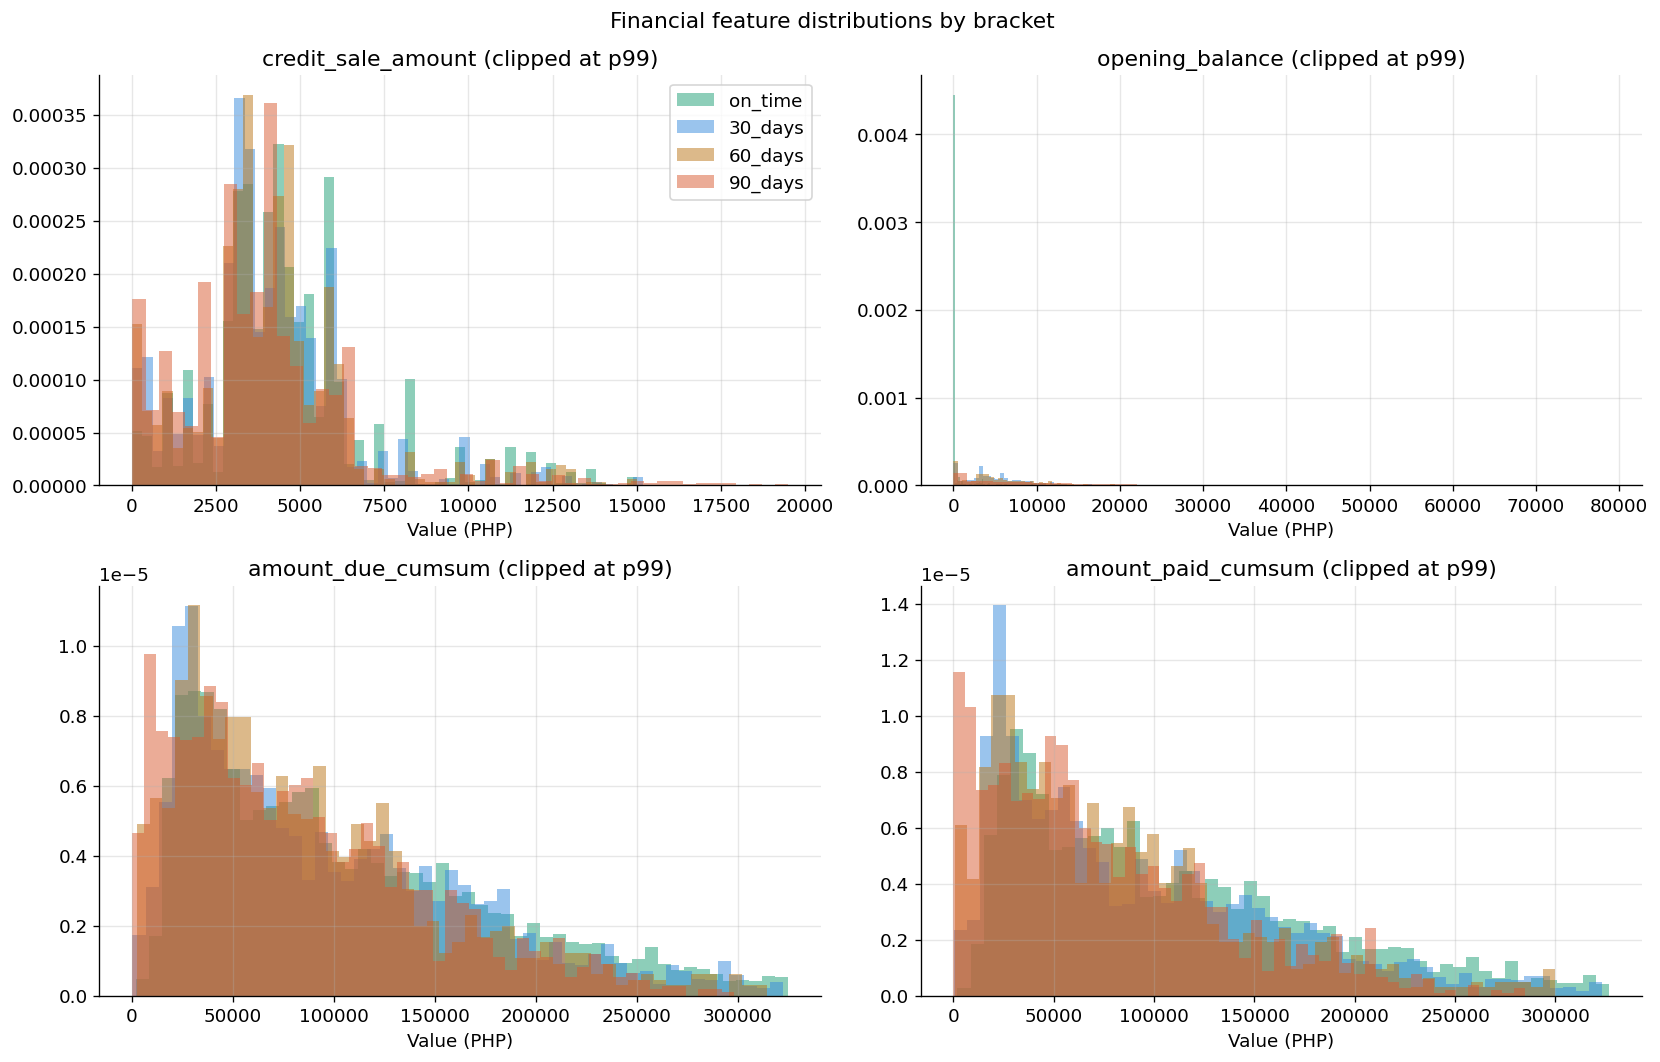

In [10]:
fin_cols = ['credit_sale_amount', 'opening_balance', 'amount_due_cumsum', 'amount_paid_cumsum']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(fin_cols):
    for bracket in BRACKET_ORDER:
        vals = df[df['dtp_bracket'] == bracket][col].dropna()
        p99 = vals.quantile(0.99)
        vals = vals[vals <= p99]
        axes[i].hist(vals, bins=50, alpha=0.5, label=bracket, color=BRACKET_COLORS[bracket], density=True)
    axes[i].set_title(f'{col} (clipped at p99)')
    axes[i].set_xlabel('Value (PHP)')
    if i == 0:
        axes[i].legend()

plt.suptitle('Financial feature distributions by bracket', fontsize=13)
plt.tight_layout()
plt.show()

Opening balance stats by bracket:
              count     mean      std  min     25%     50%      75%       max
dtp_bracket                                                                  
on_time      3844.0    691.0   2900.0  0.0     0.0     0.0      0.0   82180.0
30_days      2880.0   5688.0   5800.0  0.0  2775.0  4500.0   7500.0   85280.0
60_days      1054.0   6357.0   6326.0  0.0  2456.0  4675.0   8819.0   68306.0
90_days      1838.0  11605.0  15075.0  0.0  2250.0  7646.0  16244.0  214021.0

Payment ratio (paid/due) by bracket:
              count   mean    std    min    25%    50%    75%     max
dtp_bracket                                                          
on_time      3844.0  1.035  0.269  0.143  1.000  1.000  1.000  14.225
30_days      2880.0  0.952  0.354  0.014  0.886  0.942  0.976   7.659
60_days      1054.0  0.929  0.337  0.039  0.871  0.935  0.972   5.118
90_days      1838.0  0.918  1.038  0.000  0.747  0.887  0.973  37.700


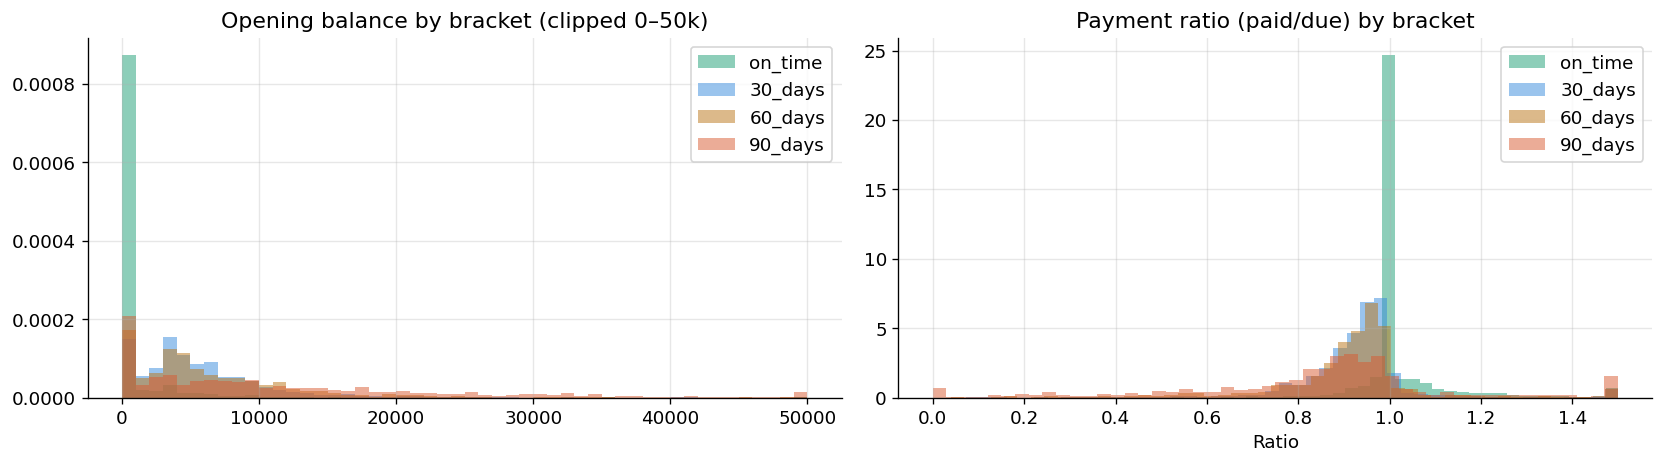

In [11]:
# Opening balance is the strongest predictor — analyse it carefully
print('Opening balance stats by bracket:')
print(df.groupby('dtp_bracket')['opening_balance'].describe().round(0))

# Key engineered feature: payment ratio
df['payment_ratio'] = df['amount_paid_cumsum'] / df['amount_due_cumsum'].replace(0, np.nan)
print('\nPayment ratio (paid/due) by bracket:')
print(df.groupby('dtp_bracket')['payment_ratio'].describe().round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
# Opening balance
for b in BRACKET_ORDER:
    vals = df[df['dtp_bracket']==b]['opening_balance'].clip(0, 50000)
    axes[0].hist(vals, bins=50, alpha=0.5, label=b, color=BRACKET_COLORS[b], density=True)
axes[0].set_title('Opening balance by bracket (clipped 0–50k)')
axes[0].legend()

# Payment ratio
for b in BRACKET_ORDER:
    vals = df[df['dtp_bracket']==b]['payment_ratio'].clip(0, 1.5).dropna()
    axes[1].hist(vals, bins=50, alpha=0.5, label=b, color=BRACKET_COLORS[b], density=True)
axes[1].set_title('Payment ratio (paid/due) by bracket')
axes[1].set_xlabel('Ratio')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Plan type analysis

            n  on_time  30_days  60_days  90_days
Plan                                             
Plan A    706    0.349    0.267    0.099    0.285
Plan B   2975    0.469    0.301    0.095    0.134
Plan C   6231    0.392    0.315    0.117    0.177
Plan D    281    0.092    0.111    0.123    0.674
Plan E     42    0.000    0.000    0.119    0.881
Unknown   115    0.057    0.190    0.171    0.581


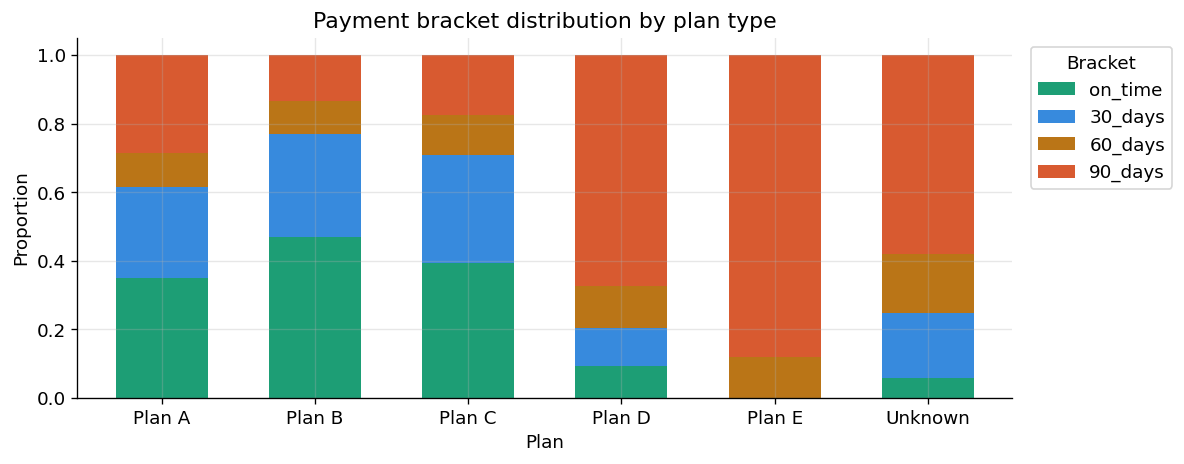


Key: Plan D and Plan E are near-certain late payers (>67% and >88% 90_days).
Plan B has the best payment profile (47% on_time).


In [12]:
plan_cols = ['plan_type_Plan - A','plan_type_Plan - B','plan_type_Plan - C',
             'plan_type_Plan - D','plan_type_Plan - E','plan_type_nan']
plan_labels = ['Plan A','Plan B','Plan C','Plan D','Plan E','Unknown']

# Build summary per plan
rows = []
for col, label in zip(plan_cols, plan_labels):
    sub = df[df[col]==1]
    n = len(sub)
    if n < 5: continue
    dist = sub['dtp_bracket'].value_counts(normalize=True).reindex(BRACKET_ORDER, fill_value=0)
    rows.append({'Plan': label, 'n': n, **dist.round(3).to_dict()})

plan_df = pd.DataFrame(rows).set_index('Plan')
print(plan_df)

# Stacked bar
plan_df[BRACKET_ORDER].plot(kind='bar', stacked=True, figsize=(10, 4),
                             color=PALETTE, width=0.6)
plt.title('Payment bracket distribution by plan type')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Bracket', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

print('\nKey: Plan D and Plan E are near-certain late payers (>67% and >88% 90_days).')
print('Plan B has the best payment profile (47% on_time).')

## 8. Temporal patterns & seasonality

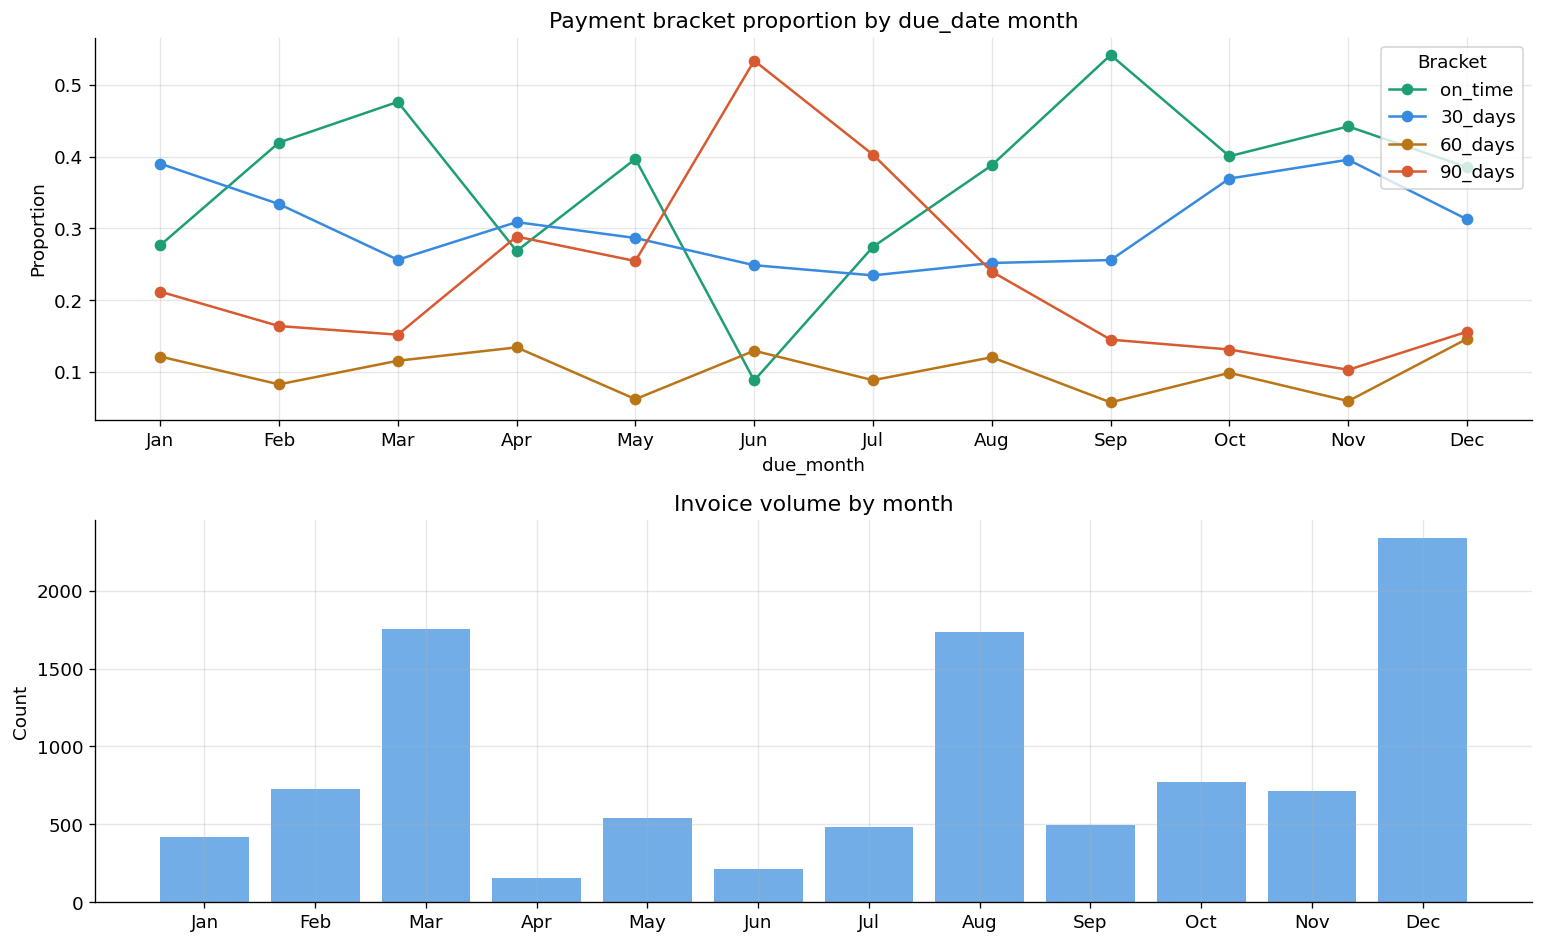


June and July have dramatically elevated 90_day rates (53%, 40%).
September has the highest on_time rate (54%).
Recommendation: add month and quarter as features.


In [13]:
# Monthly seasonality
monthly = df.groupby('due_month')['dtp_bracket'].value_counts(normalize=True).unstack()[BRACKET_ORDER]

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

monthly.plot(ax=axes[0], color=PALETTE, marker='o')
axes[0].set_title('Payment bracket proportion by due_date month')
axes[0].set_ylabel('Proportion')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
axes[0].legend(title='Bracket', loc='upper right')

# Volume per month
vol = df.groupby('due_month').size()
axes[1].bar(vol.index, vol.values, color='#378ADD', alpha=0.7)
axes[1].set_title('Invoice volume by month')
axes[1].set_ylabel('Count')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])

plt.tight_layout()
plt.show()

print('\nJune and July have dramatically elevated 90_day rates (53%, 40%).')
print('September has the highest on_time rate (54%).')
print('Recommendation: add month and quarter as features.')

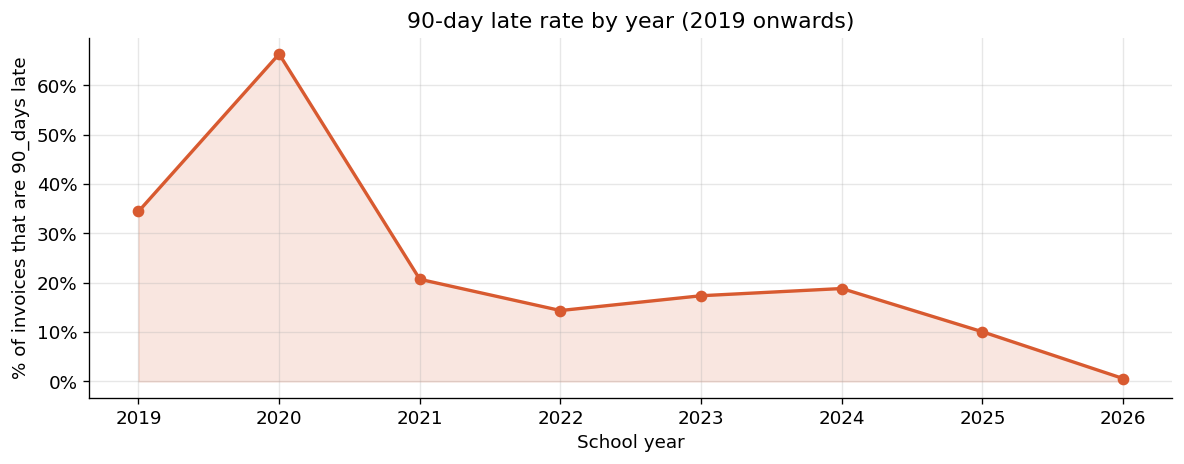


Strong downward trend in 90_days rate over time.
Pre-2019 data has very different label distribution — consider excluding 2016-2018.


In [14]:
# Year-over-year trend in 90_days rate
yearly_90 = df[df['due_year'] >= 2019].groupby('due_year').apply(
    lambda x: (x['dtp_bracket'] == '90_days').mean()
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(yearly_90.index, yearly_90.values * 100, marker='o', color='#D85A30', linewidth=2)
ax.fill_between(yearly_90.index, yearly_90.values * 100, alpha=0.15, color='#D85A30')
ax.set_title('90-day late rate by year (2019 onwards)')
ax.set_ylabel('% of invoices that are 90_days late')
ax.set_xlabel('School year')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.show()

print('\nStrong downward trend in 90_days rate over time.')
print('Pre-2019 data has very different label distribution — consider excluding 2016-2018.')

## 9. Repeat-payer behaviour & bracket transitions

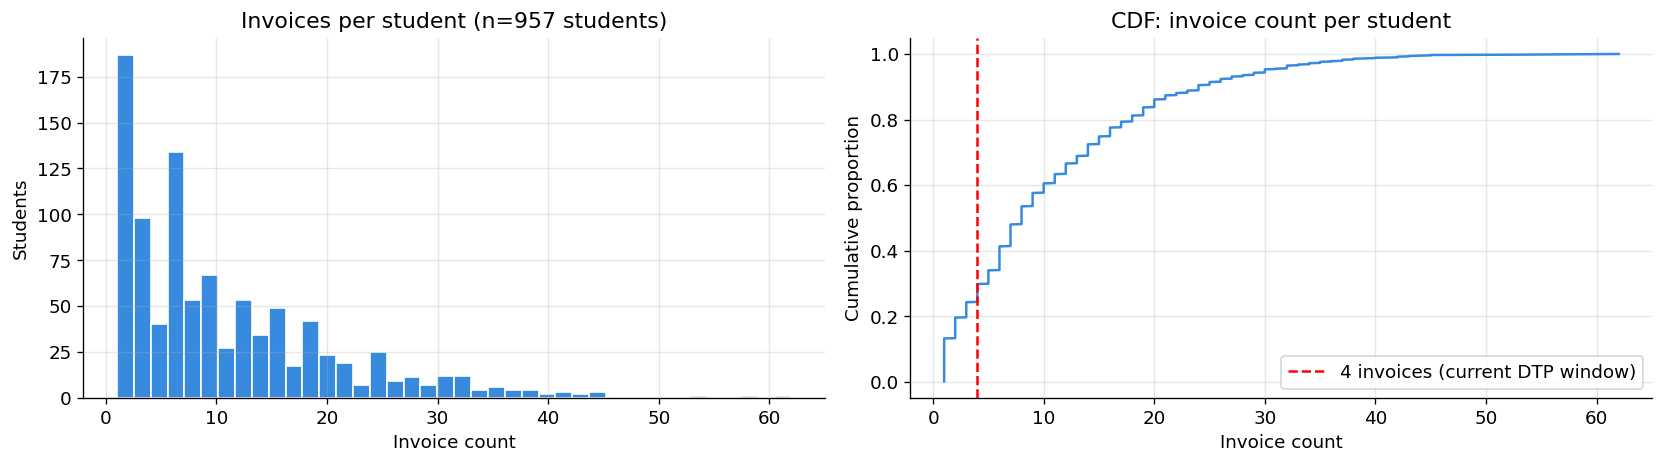

70.2% of students have more than 4 invoices (could support longer DTP window)
46.5% of students have more than 8 invoices


In [15]:
# Invoices per student
inv_per_student = df.groupby('student_id_pseudonimized').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(inv_per_student.values, bins=40, color='#378ADD', edgecolor='white')
axes[0].set_title(f'Invoices per student (n={len(inv_per_student):,} students)')
axes[0].set_xlabel('Invoice count')
axes[0].set_ylabel('Students')

# CDF
sorted_vals = np.sort(inv_per_student.values)
cdf = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
axes[1].plot(sorted_vals, cdf, color='#378ADD')
axes[1].axvline(4, color='red', linestyle='--', label='4 invoices (current DTP window)')
axes[1].set_title('CDF: invoice count per student')
axes[1].set_xlabel('Invoice count')
axes[1].set_ylabel('Cumulative proportion')
axes[1].legend()

plt.tight_layout()
plt.show()

pct_above_4 = (inv_per_student > 4).mean()
pct_above_8 = (inv_per_student > 8).mean()
print(f'{pct_above_4:.1%} of students have more than 4 invoices (could support longer DTP window)')
print(f'{pct_above_8:.1%} of students have more than 8 invoices')

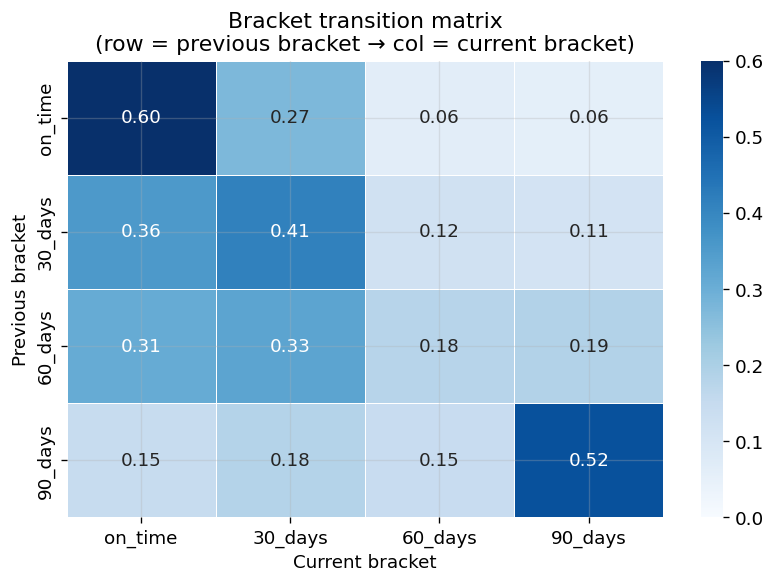

Key transitions:
  on_time → on_time:   60.5% (strong persistence)
  90_days → 90_days:   52.5% (chronic late payers)
  on_time → 90_days:   5.8%
  90_days → on_time:   14.6% (recovery rate)

Recommendation: add prev_bracket as a feature (label-encoded).


In [16]:
# Bracket transition matrix
df_sorted = df.dropna(subset=['dtp_bracket']).sort_values(['student_id_pseudonimized', 'due_date'])
df_sorted['prev_bracket'] = df_sorted.groupby('student_id_pseudonimized')['dtp_bracket'].shift(1)
transitions = df_sorted.dropna(subset=['prev_bracket'])

trans_matrix = pd.crosstab(
    transitions['prev_bracket'], transitions['dtp_bracket'],
    normalize='index'
).reindex(index=BRACKET_ORDER, columns=BRACKET_ORDER, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    trans_matrix, annot=True, fmt='.2f', cmap='Blues',
    linewidths=0.5, ax=ax, vmin=0, vmax=0.6
)
ax.set_title('Bracket transition matrix\n(row = previous bracket → col = current bracket)')
ax.set_xlabel('Current bracket')
ax.set_ylabel('Previous bracket')
plt.tight_layout()
plt.show()

print('Key transitions:')
print(f'  on_time → on_time:   {trans_matrix.loc["on_time","on_time"]:.1%} (strong persistence)')
print(f'  90_days → 90_days:   {trans_matrix.loc["90_days","90_days"]:.1%} (chronic late payers)')
print(f'  on_time → 90_days:   {trans_matrix.loc["on_time","90_days"]:.1%}')
print(f'  90_days → on_time:   {trans_matrix.loc["90_days","on_time"]:.1%} (recovery rate)')
print('\nRecommendation: add prev_bracket as a feature (label-encoded).')

In [17]:
# Chronic late payers: students who are ALWAYS 90_days
student_brackets = df_sorted.groupby('student_id_pseudonimized')['dtp_bracket'].value_counts(normalize=True).unstack(fill_value=0)

if '90_days' in student_brackets.columns:
    chronic = (student_brackets['90_days'] >= 0.75)
    consistent_on_time = (student_brackets.get('on_time', pd.Series(0, index=student_brackets.index)) >= 0.75)
    print(f'Chronic late payers (>=75% invoices are 90_days): {chronic.sum()} students ({chronic.mean():.1%})')
    print(f'Consistent on-time (>=75% on_time): {consistent_on_time.sum()} students ({consistent_on_time.mean():.1%})')

# Streak features
def consecutive_streak(series, target_val):
    streak = 0
    result = []
    for val in series:
        if val == target_val:
            streak += 1
        else:
            streak = 0
        result.append(streak)
    return result

df_sorted['on_time_streak'] = df_sorted.groupby('student_id_pseudonimized')['dtp_bracket'].transform(
    lambda x: consecutive_streak(x, 'on_time')
)

print('\nMean on_time streak by bracket:')
print(df_sorted.groupby('dtp_bracket')['on_time_streak'].mean().round(2))
print('\nRecommendation: add on_time_streak and late_streak as features.')

Chronic late payers (>=75% invoices are 90_days): 106 students (11.2%)
Consistent on-time (>=75% on_time): 180 students (19.1%)

Mean on_time streak by bracket:
dtp_bracket
on_time    2.54
30_days    0.00
60_days    0.00
90_days    0.00
Name: on_time_streak, dtype: float64

Recommendation: add on_time_streak and late_streak as features.


## 10. Outlier audit

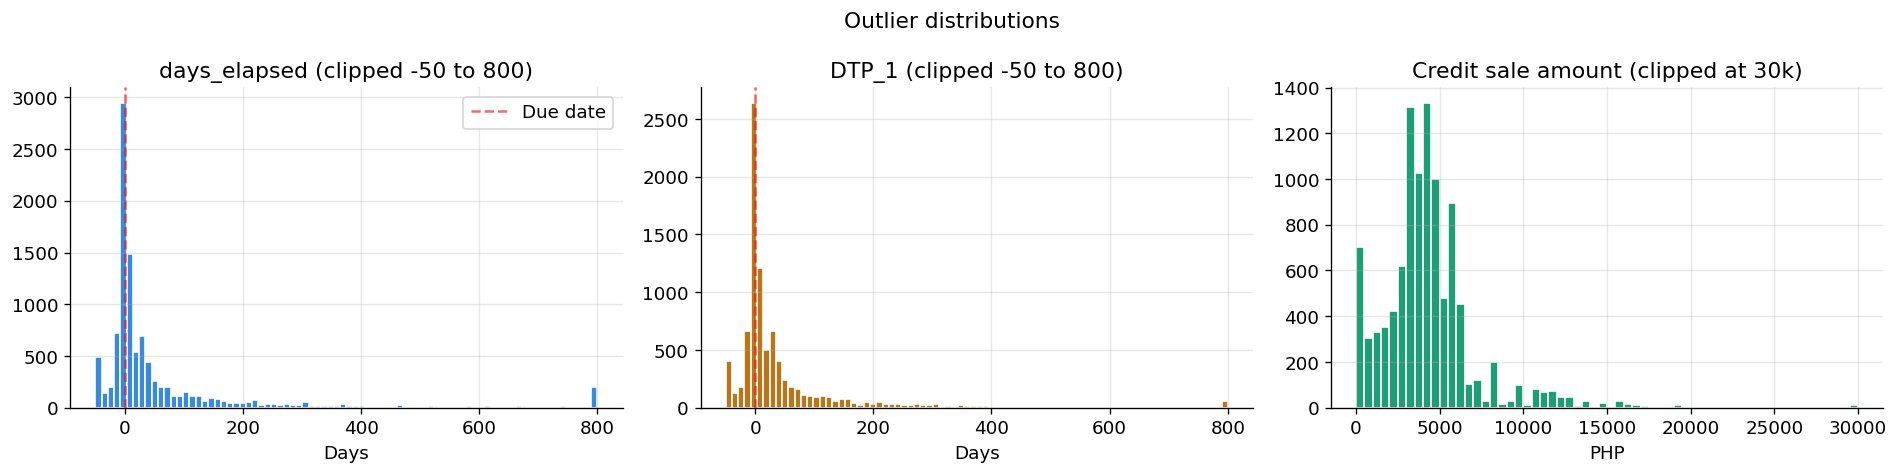

Negative days_elapsed (paid before due): 3,448
days_elapsed > 730 (2+ years): 240
dtp_1 > 365: 247
credit_sale_amount > 50k: 6

Recommendation: winsorise DTP features at p1/p99 before training.


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# days_elapsed_until_fully_paid
axes[0].hist(df['days_elapsed_until_fully_paid'].clip(-50, 800), bins=80, color='#378ADD', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', alpha=0.6, label='Due date')
axes[0].set_title('days_elapsed (clipped -50 to 800)')
axes[0].set_xlabel('Days')
axes[0].legend()

# DTP_1 outliers
axes[1].hist(df['dtp_1'].dropna().clip(-50, 800), bins=80, color='#BA7517', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', alpha=0.6)
axes[1].set_title('DTP_1 (clipped -50 to 800)')
axes[1].set_xlabel('Days')

# Credit sale amount
axes[2].hist(df['credit_sale_amount'].clip(0, 30000), bins=60, color='#1D9E75', edgecolor='white')
axes[2].set_title('Credit sale amount (clipped at 30k)')
axes[2].set_xlabel('PHP')

plt.suptitle('Outlier distributions', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Negative days_elapsed (paid before due): {(df["days_elapsed_until_fully_paid"] < 0).sum():,}')
print(f'days_elapsed > 730 (2+ years): {(df["days_elapsed_until_fully_paid"] > 730).sum():,}')
print(f'dtp_1 > 365: {(df["dtp_1"] > 365).sum():,}')
print(f'credit_sale_amount > 50k: {(df["credit_sale_amount"] > 50000).sum():,}')
print('\nRecommendation: winsorise DTP features at p1/p99 before training.')

## 11. Correlation & feature importance signals

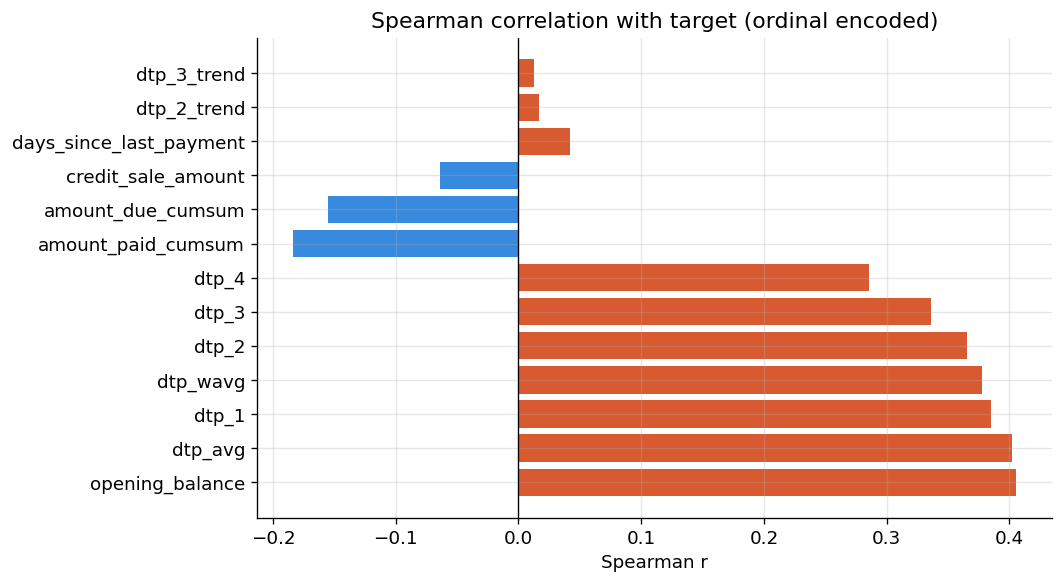

                feature  spearman_r       p_value
        opening_balance    0.405726  0.000000e+00
                dtp_avg    0.402422  0.000000e+00
                  dtp_1    0.384863 1.173388e-309
               dtp_wavg    0.377831  0.000000e+00
                  dtp_2    0.365223 9.622072e-255
                  dtp_3    0.335895 5.784779e-195
                  dtp_4    0.285710 1.026370e-126
     amount_paid_cumsum   -0.183818  4.653787e-79
      amount_due_cumsum   -0.155523  4.816921e-57
     credit_sale_amount   -0.063613  9.330902e-11
days_since_last_payment    0.042333  1.646258e-05
            dtp_2_trend    0.016327  9.673290e-02
            dtp_3_trend    0.012415  2.066196e-01


In [19]:
from scipy.stats import spearmanr

num_features = [
    'dtp_1','dtp_2','dtp_3','dtp_4','dtp_avg','dtp_wavg',
    'dtp_2_trend','dtp_3_trend','days_since_last_payment',
    'credit_sale_amount','opening_balance',
    'amount_due_cumsum','amount_paid_cumsum',
]

corr_results = []
for col in num_features:
    valid = df[['target_enc', col]].dropna()
    r, p = spearmanr(valid['target_enc'], valid[col])
    corr_results.append({'feature': col, 'spearman_r': r, 'p_value': p, 'abs_r': abs(r)})

corr_df = pd.DataFrame(corr_results).sort_values('abs_r', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#D85A30' if r > 0 else '#378ADD' for r in corr_df['spearman_r']]
bars = ax.barh(corr_df['feature'], corr_df['spearman_r'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Spearman correlation with target (ordinal encoded)')
ax.set_xlabel('Spearman r')
plt.tight_layout()
plt.show()

print(corr_df[['feature','spearman_r','p_value']].to_string(index=False))

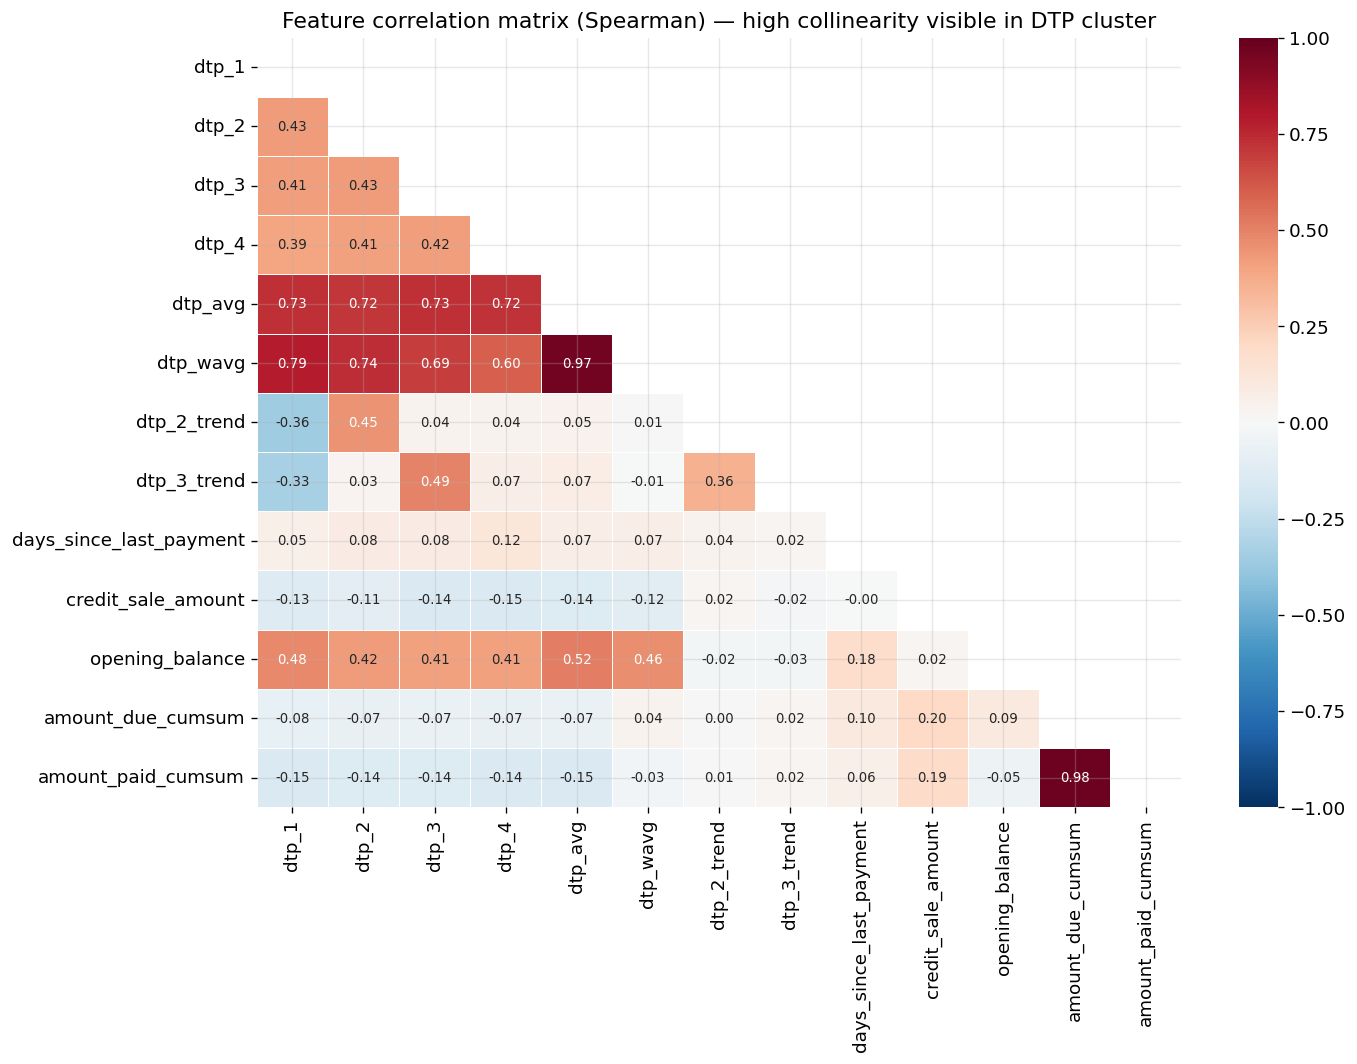

Feature pairs with |r| > 0.80 (high collinearity — candidates for VIF pruning):
  amount_due_cumsum <-> amount_paid_cumsum:  r=0.978
  dtp_avg <-> dtp_wavg:  r=0.968


In [20]:
# Full correlation matrix
corr_matrix = df[num_features].corr(method='spearman')

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.4, ax=ax, annot_kws={'size': 8}
)
ax.set_title('Feature correlation matrix (Spearman) — high collinearity visible in DTP cluster')
plt.tight_layout()
plt.show()

# Flag high correlations
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i,j]
        if abs(r) > 0.8:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], round(r, 3)))

print('Feature pairs with |r| > 0.80 (high collinearity — candidates for VIF pruning):')
for a, b, r in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
    print(f'  {a} <-> {b}:  r={r}')

## 12. Feature engineering recommendations

In [21]:
print('=' * 70)
print('FEATURE ENGINEERING RECOMMENDATIONS')
print('=' * 70)

recommendations = [
    ('HIGH IMPACT', 'opening_balance_flag',
     'Binary: opening_balance > 0. Strongest separator: 83% of zero-OB are on_time.'),
    ('HIGH IMPACT', 'payment_ratio',
     'amount_paid_cumsum / amount_due_cumsum. Measures cumulative repayment discipline.'),
    ('HIGH IMPACT', 'prev_bracket_encoded',
     'Previous bracket label (0-3). 60% on_time->on_time; 52% 90_days->90_days persistence.'),
    ('HIGH IMPACT', 'due_month / due_quarter',
     'June=53% 90_days, Sep=54% on_time. Strong seasonal signal not currently used.'),
    ('MEDIUM IMPACT', 'early_payer_flag',
     'Binary: dtp_1 < 0. Early payers are almost never 90_days late.'),
    ('MEDIUM IMPACT', 'on_time_streak',
     'Consecutive on-time count. Captures momentum / habit.'),
    ('MEDIUM IMPACT', 'dtp_rolling_std',
     'Std dev of dtp_1..4. High variance = erratic payer, distinct from consistently late.'),
    ('MEDIUM IMPACT', 'dtp_max',
     'Max of dtp_1..4. Worst recent payment. Complements the average.'),
    ('MEDIUM IMPACT', 'plan_type_risk_score',
     'Ordinal encode plan type by 90_day rate: E=4, D=3, nan=2, A=1, C=0.5, B=0.'),
    ('LOW IMPACT', 'dtp_6m_mean / dtp_6m_std',
     'Extend DTP window from 4 to 8 invoices for students with enough history.'),
    ('DATA QUALITY', 'exclude_pre_2019',
     '2016-2018 data is 71-100% 90_days — very different distribution, may hurt generalisation.'),
    ('DATA QUALITY', 'winsorise_dtp',
     'Clip DTP features at p1/p99 before training. 247 values > 365 days are likely data errors.'),
]

for priority, name, description in recommendations:
    print(f'\n[{priority}] {name}')
    print(f'  {description}')

FEATURE ENGINEERING RECOMMENDATIONS

[HIGH IMPACT] opening_balance_flag
  Binary: opening_balance > 0. Strongest separator: 83% of zero-OB are on_time.

[HIGH IMPACT] payment_ratio
  amount_paid_cumsum / amount_due_cumsum. Measures cumulative repayment discipline.

[HIGH IMPACT] prev_bracket_encoded
  Previous bracket label (0-3). 60% on_time->on_time; 52% 90_days->90_days persistence.

[HIGH IMPACT] due_month / due_quarter
  June=53% 90_days, Sep=54% on_time. Strong seasonal signal not currently used.

[MEDIUM IMPACT] early_payer_flag
  Binary: dtp_1 < 0. Early payers are almost never 90_days late.

[MEDIUM IMPACT] on_time_streak
  Consecutive on-time count. Captures momentum / habit.

[MEDIUM IMPACT] dtp_rolling_std
  Std dev of dtp_1..4. High variance = erratic payer, distinct from consistently late.

[MEDIUM IMPACT] dtp_max
  Max of dtp_1..4. Worst recent payment. Complements the average.

[MEDIUM IMPACT] plan_type_risk_score
  Ordinal encode plan type by 90_day rate: E=4, D=3, nan

In [22]:
# Demonstrate the top candidate features
df['opening_balance_flag'] = (df['opening_balance'] > 0).astype(int)
df['payment_ratio'] = df['amount_paid_cumsum'] / df['amount_due_cumsum'].replace(0, np.nan)
df['dtp_rolling_std'] = df[['dtp_1','dtp_2','dtp_3','dtp_4']].std(axis=1)
df['dtp_max'] = df[['dtp_1','dtp_2','dtp_3','dtp_4']].max(axis=1)
df['early_payer_flag'] = (df['dtp_1'] < 0).astype(float)

new_features = ['opening_balance_flag','payment_ratio','dtp_rolling_std','dtp_max','early_payer_flag','due_month','due_quarter']

print('Spearman correlation of NEW engineered features with target:')
for col in new_features:
    valid = df[['target_enc', col]].dropna()
    if len(valid) < 100: continue
    r, p = spearmanr(valid['target_enc'], valid[col])
    print(f'  {col:<30} r={r:+.4f}  n={len(valid):,}')

Spearman correlation of NEW engineered features with target:
  opening_balance_flag           r=+0.4538  n=10,350
  payment_ratio                  r=-0.3779  n=10,313
  dtp_rolling_std                r=+0.2894  n=8,216
  dtp_max                        r=+0.3944  n=9,145
  early_payer_flag               r=-0.2217  n=10,350
  due_month                      r=+0.0273  n=10,350
  due_quarter                    r=+0.0406  n=10,350
